# Système explicable d'aide à la décision — Prédiction du risque de mortalité en soins intensifs

**Projet de portfolio technique **
Auteur : Dini Ahamada

## Objectif
Construire un modèle de prédiction du risque de mortalité en soins intensifs à partir de données cliniques
multimodales (signes vitaux, résultats de laboratoire, descripteurs généraux), puis **expliquer** chaque
prédiction avec SHAP — afin de produire une sortie interprétable, proche de ce qu'un système d'aide à la
décision clinique (SIADC) devrait fournir à un médecin.

## Jeu de données
**PhysioNet/Computing in Cardiology Challenge 2012** — *Predicting Mortality of ICU Patients*
(Silva et al., 2012). 4 000 séjours en soins intensifs adultes (Training Set A), avec :
- 48 heures de séries temporelles cliniques (37 variables : fréquence cardiaque, pression artérielle,
  créatinine, glucose, etc.)
- 5 descripteurs généraux (âge, sexe, taille, poids, type d'unité de soins)
- Une étiquette binaire : décès intra-hospitalier ou non

Accès **entièrement libre**, sans processus d'accréditation (contrairement à MIMIC-III complet).



## Plan du notebook
1. Installation et téléchargement des données
2. Chargement et mise en forme (agrégation des séries temporelles par patient)
3. Prétraitement (valeurs manquantes, jeu d'entraînement/test)
4. Modélisation (Random Forest, puis XGBoost)
5. Évaluation (AUROC, matrice de confusion)
6. **Explicabilité clinique avec SHAP** (importance globale + explication par patient)
7. Traduction d'une explication SHAP en recommandation textuelle simple


## 1. Installation et téléchargement des données

In [1]:
# Bibliothèques nécessaires (scikit-learn, pandas, xgboost sont déjà présents sur Colab)
!pip install shap --quiet


In [2]:
# Téléchargement du jeu de données PhysioNet Challenge 2012 (Training Set A) — accès libre
!wget -q "https://physionet.org/files/challenge-2012/1.0.0/set-a.tar.gz?download" -O set-a.tar.gz
!wget -q "https://physionet.org/files/challenge-2012/1.0.0/Outcomes-a.txt?download" -O Outcomes-a.txt
!tar -xzf set-a.tar.gz

import os
print("Nombre de dossiers patients:", len(os.listdir("set-a")))


Nombre de dossiers patients: 4000


## 2. Chargement et agrégation des données

Chaque patient est représenté par un fichier `.txt` contenant une série temporelle irrégulière
(`Time, Parameter, Value`) sur 48 heures. Pour construire un jeu de données tabulaire exploitable par
un modèle de type Random Forest / XGBoost, on **agrège chaque variable clinique** en un petit ensemble
de statistiques résumées (min, max, moyenne, dernière valeur) — une approche standard et interprétable
pour ce type de données cliniques irrégulières.

In [3]:
import pandas as pd
import numpy as np
import glob

# Variables cliniques suivies dans le challenge (hors descripteurs généraux)
TIME_SERIES_VARS = [
    'Albumin','ALP','ALT','AST','Bilirubin','BUN','Cholesterol','Creatinine','DiasABP','FiO2','GCS',
    'Glucose','HCO3','HCT','HR','K','Lactate','Mg','MAP','MechVent','Na','NIDiasABP','NIMAP','NISysABP',
    'PaCO2','PaO2','pH','Platelets','RespRate','SaO2','SysABP','Temp','TroponinI','TroponinT','Urine','WBC'
]
GENERAL_VARS = ['Age', 'Gender', 'Height', 'ICUType', 'Weight']

def load_patient_record(filepath):
    df = pd.read_csv(filepath)
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df.loc[df['Value'] == -1, 'Value'] = np.nan  # -1 = valeur manquante (convention du challenge)
    record_id = int(df.loc[df['Parameter'] == 'RecordID', 'Value'].iloc[0])

    features = {'RecordID': record_id}

    # Descripteurs généraux : valeur unique par patient
    for var in GENERAL_VARS:
        vals = df.loc[df['Parameter'] == var, 'Value']
        features[var] = vals.iloc[0] if len(vals) else np.nan

    # Séries temporelles : agrégation min / max / moyenne / dernière valeur
    for var in TIME_SERIES_VARS:
        vals = df.loc[df['Parameter'] == var, 'Value'].dropna()
        if len(vals):
            features[f'{var}_min'] = vals.min()
            features[f'{var}_max'] = vals.max()
            features[f'{var}_mean'] = vals.mean()
            features[f'{var}_last'] = vals.iloc[-1]
        else:
            features[f'{var}_min'] = np.nan
            features[f'{var}_max'] = np.nan
            features[f'{var}_mean'] = np.nan
            features[f'{var}_last'] = np.nan

    return features

files = sorted(glob.glob("set-a/*.txt"))
print(f"Traitement de {len(files)} dossiers patients...")

records = [load_patient_record(f) for f in files]
patients_df = pd.DataFrame(records)
print("Dimensions du jeu de données agrégé :", patients_df.shape)
patients_df.head()


Traitement de 4000 dossiers patients...
Dimensions du jeu de données agrégé : (4000, 150)


,RecordID,Age,Gender,Height,ICUType,Weight,Albumin_min,Albumin_max,Albumin_mean,Albumin_last,...,TroponinT_mean,TroponinT_last,Urine_min,Urine_max,Urine_mean,Urine_last,WBC_min,WBC_max,WBC_mean,WBC_last
0,132539,54.0,0.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,900.0,171.052632,280.0,9.4,11.2,10.300000,9.4
1,132540,76.0,1.0,175.3,2.0,76.0,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,770.0,151.560976,220.0,7.4,13.3,11.266667,13.3
2,132541,44.0,0.0,NaN,3.0,56.7,2.3,2.7,2.5,2.3,...,NaN,NaN,18.0,425.0,124.951220,35.0,3.7,6.2,4.700000,6.2
3,132543,68.0,1.0,180.3,3.0,84.6,4.4,4.4,4.4,4.4,...,NaN,NaN,100.0,700.0,545.833333,550.0,7.9,11.5,9.400000,7.9
4,132545,88.0,0.0,NaN,3.0,NaN,3.3,3.3,3.3,3.3,...,NaN,NaN,16.0,220.0,62.131579,80.0,3.8,4.8,4.300000,4.8


In [4]:
# Fusion avec les étiquettes de mortalité intra-hospitalière
outcomes = pd.read_csv("Outcomes-a.txt")
outcomes = outcomes[['RecordID', 'In-hospital_death']]

data = patients_df.merge(outcomes, on='RecordID', how='inner')
print("Taux de mortalité intra-hospitalière :", round(data['In-hospital_death'].mean() * 100, 1), "%")
data.head()


Taux de mortalité intra-hospitalière : 13.8 %


,RecordID,Age,Gender,Height,ICUType,Weight,Albumin_min,Albumin_max,Albumin_mean,Albumin_last,...,TroponinT_last,Urine_min,Urine_max,Urine_mean,Urine_last,WBC_min,WBC_max,WBC_mean,WBC_last,In-hospital_death
0,132539,54.0,0.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,900.0,171.052632,280.0,9.4,11.2,10.300000,9.4,0
1,132540,76.0,1.0,175.3,2.0,76.0,NaN,NaN,NaN,NaN,...,NaN,0.0,770.0,151.560976,220.0,7.4,13.3,11.266667,13.3,0
2,132541,44.0,0.0,NaN,3.0,56.7,2.3,2.7,2.5,2.3,...,NaN,18.0,425.0,124.951220,35.0,3.7,6.2,4.700000,6.2,0
3,132543,68.0,1.0,180.3,3.0,84.6,4.4,4.4,4.4,4.4,...,NaN,100.0,700.0,545.833333,550.0,7.9,11.5,9.400000,7.9,0
4,132545,88.0,0.0,NaN,3.0,NaN,3.3,3.3,3.3,3.3,...,NaN,16.0,220.0,62.131579,80.0,3.8,4.8,4.300000,4.8,0


## 3. Prétraitement : valeurs manquantes et séparation entraînement / test

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = data.drop(columns=['RecordID', 'In-hospital_death'])
y = data['In-hospital_death']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputation par la médiane (robuste aux valeurs extrêmes fréquentes en clinique)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=feature_names, index=X_test.index)

print("Entraînement :", X_train_imp.shape, " | Test :", X_test_imp.shape)


Entraînement : (3200, 149)  | Test : (800, 149)


## 4. Modélisation

On entraîne deux modèles pour comparaison :
- **Random Forest** — robuste, bonne baseline, facilement explicable avec SHAP
- **XGBoost** — généralement plus performant sur données tabulaires cliniques avec valeurs manquantes

(Les deux modèles sont directement issus du contenu du cours *Machine Learning A-Z* — Partie 3 : Classification et Partie 10 : Model Selection & Boosting.)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_imp, y_train)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train_imp, y_train)

print("Modèles entraînés.")


Modèles entraînés.


## 5. Évaluation


=== Random Forest ===
AUROC : 0.863
              precision    recall  f1-score   support

      Survie       0.93      0.87      0.90       689
       Décès       0.42      0.58      0.49       111

    accuracy                           0.83       800
   macro avg       0.68      0.73      0.69       800
weighted avg       0.86      0.83      0.84       800


=== XGBoost ===
AUROC : 0.887
              precision    recall  f1-score   support

      Survie       0.93      0.91      0.92       689
       Décès       0.51      0.57      0.54       111

    accuracy                           0.86       800
   macro avg       0.72      0.74      0.73       800
weighted avg       0.87      0.86      0.87       800



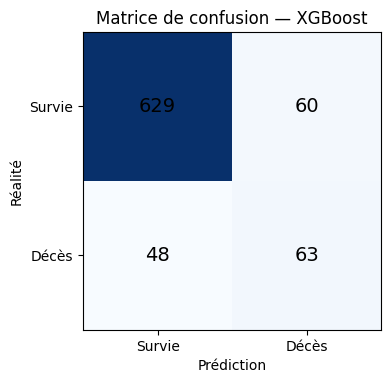

In [7]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

for name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    proba = model.predict_proba(X_test_imp)[:, 1]
    preds = model.predict(X_test_imp)
    auc = roc_auc_score(y_test, proba)
    print(f"\n=== {name} ===")
    print(f"AUROC : {auc:.3f}")
    print(classification_report(y_test, preds, target_names=['Survie', 'Décès']))

# Matrice de confusion du meilleur modèle (à ajuster selon les résultats obtenus)
cm = confusion_matrix(y_test, xgb_model.predict(X_test_imp))
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Survie', 'Décès'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Survie', 'Décès'])
ax.set_xlabel('Prédiction'); ax.set_ylabel('Réalité')
ax.set_title('Matrice de confusion — XGBoost')
plt.tight_layout()
plt.show()


## 6. Explicabilité clinique avec SHAP

C'est ici que le projet se distingue d'un simple exercice de classification : on ne se contente pas de
prédire un risque, on **explique pourquoi** le modèle l'estime élevé — l'objectif étant de produire une
information exploitable par un clinicien, pas seulement un score opaque.

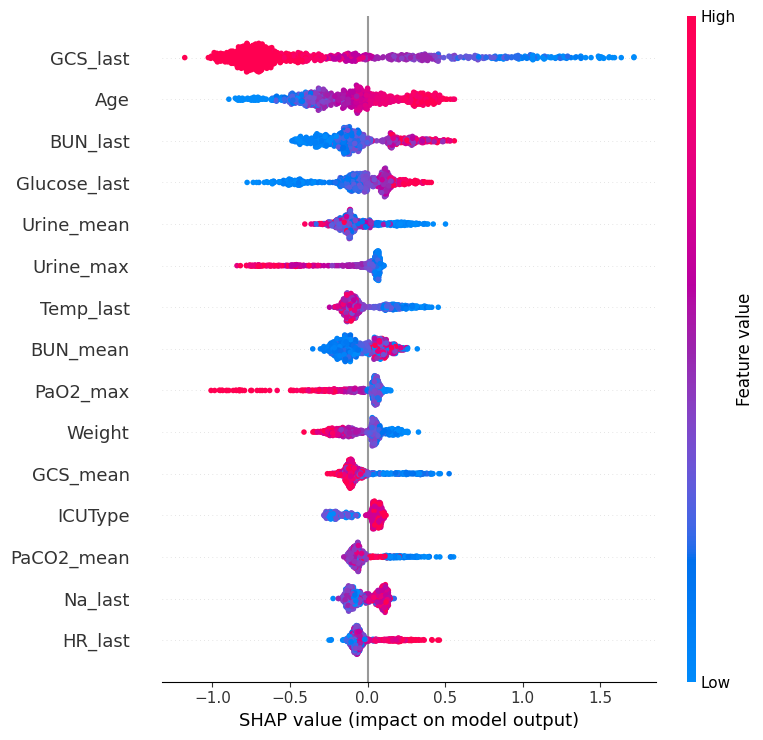

In [8]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_imp)

# Importance globale : quelles variables pèsent le plus, en moyenne, dans les prédictions du modèle
shap.summary_plot(shap_values, X_test_imp, max_display=15, show=True)


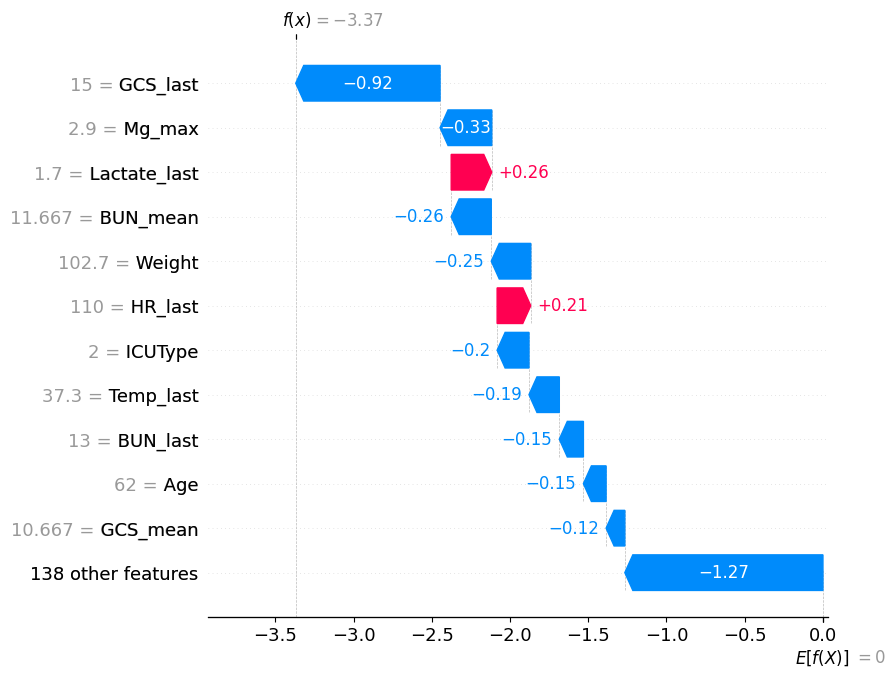

In [9]:
# Explication individuelle : pourquoi le modèle prédit-il ce risque pour CE patient précis ?
patient_index = 0  # à faire varier pour explorer différents patients du jeu de test

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[patient_index],
        base_values=explainer.expected_value,
        data=X_test_imp.iloc[patient_index],
        feature_names=feature_names
    ),
    max_display=12
)


## 7. D'une explication SHAP à une recommandation clinique en langage clair

Cette dernière étape est la plus proche, conceptuellement, de ce que devrait produire un véritable SIADC :
traduire une sortie technique (valeurs SHAP) en une phrase interprétable par un professionnel de la santé,
qui garde la décision finale entre ses mains.

In [10]:
def explication_clinique(index, top_n=3):
    row_shap = shap_values[index]
    patient = X_test_imp.iloc[index]
    proba = xgb_model.predict_proba(X_test_imp.iloc[[index]])[0, 1]

    contributions = pd.Series(row_shap, index=feature_names).sort_values(key=abs, ascending=False)
    top_features = contributions.head(top_n)

    print(f"Patient #{index} — Risque de mortalité estimé : {proba*100:.1f}%\n")
    print("Principaux facteurs contribuant à cette estimation :")
    for feat, val in top_features.items():
        direction = "augmente" if val > 0 else "diminue"
        valeur_mesuree = patient[feat]
        print(f"  • {feat} (valeur observée : {valeur_mesuree:.1f}) {direction} le risque estimé")
    print("\nCette estimation est une aide à la décision et ne remplace pas le jugement clinique.")

explication_clinique(patient_index)


Patient #0 — Risque de mortalité estimé : 3.3%

Principaux facteurs contribuant à cette estimation :
  • GCS_last (valeur observée : 15.0) diminue le risque estimé
  • Mg_max (valeur observée : 2.9) diminue le risque estimé
  • Lactate_last (valeur observée : 1.7) augmente le risque estimé

Cette estimation est une aide à la décision et ne remplace pas le jugement clinique.


## Conclusion et prochaines étapes

Ce prototype démontre, à petite échelle, les trois piliers de l'axe de recherche visé :
1. **Fusion de données cliniques multimodales** (signes vitaux + laboratoire + descripteurs généraux)
2. **Prédiction du risque** avec un modèle robuste (XGBoost)
3. **Explicabilité clinique** (SHAP) traduite en langage exploitable par un médecin

**Limites assumées** :
- Population adulte, pas pédiatrique
- Pas de traitement en temps réel (analyse rétrospective sur données statiques)
- Agrégation simple des séries temporelles (min/max/moyenne) plutôt qu'une modélisation
  séquentielle (LSTM, Transformer) — un choix délibéré pour rester réalisable en quelques jours

**Prochaines étapes envisageables** :
- Modélisation séquentielle des séries temporelles plutôt que leur agrégation
- Interface interactive simple (Streamlit/Gradio) pour simuler l'usage clinique
- Extension à des données multimodales incluant de l'imagerie
